<a href="https://colab.research.google.com/github/vighneshkhot10/CSL701-ce24_Machine-Learning-Lab/blob/main/Experiment_3_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Experiment Number 3

Name Vighnesh D Khot                                                         
Roll No : CE19

**Aim** : To implement a Multiple Linear Regression model from scratch using NumPy matrix operations to predict the selling price of used cars using multiple features from the CarDekho Used Car Dataset.


**Learning Outcomes**
•	Understand the working principle of Multiple Linear Regression.

•	Perform data preprocessing and feature engineering.

•	Convert categorical data into numerical features.

•	Standardize numerical features.

•	Implement the Ordinary Least Squares method using matrix operations.

•	Train and test a regression model without using a ready-made regression function.

•	Evaluate and interpret regression performance using RSS and R².

•	Understand the effect of individual features on the predicted price.



\### Dataset

Use the **CarDekho Used Car Dataset** (`car data.csv`). [CarDekho Used Car Dataset](https://www.kaggle.com/datasets/manishkr1754/cardekho-used-car-data)

Explain meaning of each attribute in this dataset in below comment section :


Here, **Selling_Price** is the target variable.





\# Software/Tools Required

- Python 3.x
- Google Colab / Jupyter Notebook
- NumPy
- Matplotlib

---


### Task 1: Set Up the Python Environment**

- Create a new Google Colab notebook.
- Import **NumPy** for numerical and matrix operations.
- Import **Matplotlib** for data visualization.
- Do not use ready-made machine-learning regression functions such as `LinearRegression()` from Scikit-learn.
- The regression model must be implemented using matrix operations.

---

In [ ]:
# Task 1: Set Up the Python Environment

# Import NumPy for numerical and matrix operations
import numpy as np

# Import Matplotlib for data visualization
import matplotlib.pyplot as plt

print("NumPy version:", np.__version__)
print("Python environment is ready!")

NumPy version: 2.0.2
Python environment is ready!


## Task 2: Load and Inspect the Dataset

- Download the `car data.csv` file.
- Upload the dataset to Google Colab.
- Load the dataset into Python.
- Display the first few records.
- Determine the number of rows and columns.
- Identify the numerical and categorical attributes.
- Separate `Selling_Price` as the target variable.

---

In [ ]:
# Task 2: Load and Inspect the Dataset

import pandas as pd
from google.colab import files

# Upload the dataset from your computer
uploaded = files.upload()

# Get the uploaded filename automatically
filename = next(iter(uploaded))

# Load the dataset
df = pd.read_csv(filename)

# Display the first 5 records
print("First 5 Records:")
display(df.head())

# Display number of rows and columns
print("\nDataset Shape:")
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

# Display all attribute names
print("\nAttribute Names:")
print(df.columns.tolist())

# Identify numerical attributes
numerical_attributes = df.select_dtypes(include="number").columns.tolist()

# Identify categorical attributes
categorical_attributes = df.select_dtypes(exclude="number").columns.tolist()

print("\nNumerical Attributes:")
print(numerical_attributes)

print("\nCategorical Attributes:")
print(categorical_attributes)

# Separate selling_price as the target variable
y = df["selling_price"]

print("\nTarget Variable: selling_price")
display(y.head())

Saving cardekho_dataset.csv to cardekho_dataset (2).csv
First 5 Records:


,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000



Dataset Shape:
Number of Rows: 15411
Number of Columns: 14

Attribute Names:
['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']

Numerical Attributes:
['Unnamed: 0', 'vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']

Categorical Attributes:
['car_name', 'brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']

Target Variable: selling_price


,selling_price
0,120000
1,550000
2,215000
3,226000
4,570000


## Task 3: Check and Handle Missing Data

- Check every attribute for missing or null values.
- Count the number of missing values in each column.
- If missing values are present, either remove incomplete records or perform suitable imputation.
- Verify that the final dataset does not contain missing values.
- Record the preprocessing method used.

---

In [ ]:
# Task 3: Check and Handle Missing Data

# Check and count missing values in each column
print("Missing Values Before Handling:")
print(df.isnull().sum())

# Remove rows containing missing values
df = df.dropna()

# Reset the index after removing rows
df = df.reset_index(drop=True)

# Verify that no missing values remain
print("\nMissing Values After Handling:")
print(df.isnull().sum())

# Display final dataset shape
print("\nFinal Dataset Shape:")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

# Record the preprocessing method
print("\nPreprocessing Method Used:")
print("Rows containing missing values were removed using dropna().")

Missing Values Before Handling:
Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

Missing Values After Handling:
Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

Final Dataset Shape:
Rows: 15411
Columns: 14

Preprocessing Method Used:
Rows containing missing values were removed using dropna().


## Task 4: Select and Prepare Features

- Examine all available attributes.
- Decide how `Car_Name` should be handled.
- Select meaningful predictor variables for the regression model.
- Create the predictor matrix $X$ and target vector $y$.
- Record the final list of features selected for the model.

---

In [ ]:
# Task 4: Select and Prepare Features

# Display all available attributes
print("Available Attributes:")
print(df.columns.tolist())

# Select meaningful predictor variables
features = [
    "vehicle_age",
    "km_driven",
    "seller_type",
    "fuel_type",
    "transmission_type",
    "mileage",
    "engine",
    "max_power",
    "seats"
]

# Create predictor matrix X
X = df[features].copy()

# Create target vector y
y = df["selling_price"].copy()

# Display selected features
print("\nSelected Features:")
print(features)

# Display predictor matrix
print("\nPredictor Matrix X:")
display(X.head())

# Display target vector
print("\nTarget Vector y:")
display(y.head())

# Display shapes
print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)

Available Attributes:
['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']

Selected Features:
['vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats']

Predictor Matrix X:


,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats
0,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5
1,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5
2,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5
3,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5
4,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5



Target Vector y:


,selling_price
0,120000
1,550000
2,215000
3,226000
4,570000



Shape of X: (15411, 9)
Shape of y: (15411,)


## Task 5: Encode Categorical Variables

Identify the categorical variables:

- `Fuel_Type`
- `Seller_Type`
- `Transmission`

Perform the following:

- Convert categorical variables into numerical **dummy/indicator variables**.
- Verify that all predictors are numerical after encoding.
- Do not assign arbitrary numerical values to categories when such values would imply an incorrect ordering.
- Display the transformed dataset.

---

In [ ]:
# Task 5: Encode Categorical Variables

# Identify categorical variables
categorical_variables = [
    "fuel_type",
    "seller_type",
    "transmission_type"
]

print("Categorical Variables:")
print(categorical_variables)

# Convert categorical variables into dummy/indicator variables
# drop_first=True avoids redundant dummy variables
X = pd.get_dummies(
    X,
    columns=categorical_variables,
    drop_first=True,
    dtype=int
)

# Verify that all predictors are numerical
print("\nData Types After Encoding:")
print(X.dtypes)

# Check whether any non-numerical columns remain
print("\nAre all predictors numerical?")
print(X.dtypes.apply(lambda x: np.issubdtype(x, np.number)).all())

# Display the transformed dataset
print("\nTransformed Dataset:")
display(X.head())

# Display final feature names
print("\nFinal Feature Names:")
print(X.columns.tolist())

Categorical Variables:
['fuel_type', 'seller_type', 'transmission_type']

Data Types After Encoding:
vehicle_age                       int64
km_driven                         int64
mileage                         float64
engine                            int64
max_power                       float64
seats                             int64
fuel_type_Diesel                  int64
fuel_type_Electric                int64
fuel_type_LPG                     int64
fuel_type_Petrol                  int64
seller_type_Individual            int64
seller_type_Trustmark Dealer      int64
transmission_type_Manual          int64
dtype: object

Are all predictors numerical?
True

Transformed Dataset:


,vehicle_age,km_driven,mileage,engine,max_power,seats,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_type_Manual
0,9,120000,19.70,796,46.30,5,0,0,0,1,1,0,1
1,5,20000,18.90,1197,82.00,5,0,0,0,1,1,0,1
2,11,60000,17.00,1197,80.00,5,0,0,0,1,1,0,1
3,9,37000,20.92,998,67.10,5,0,0,0,1,1,0,1
4,6,30000,22.77,1498,98.59,5,1,0,0,0,0,0,1



Final Feature Names:
['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'fuel_type_Diesel', 'fuel_type_Electric', 'fuel_type_LPG', 'fuel_type_Petrol', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'transmission_type_Manual']


## Task 6: Perform Feature Engineering

Create a new feature called `Car_Age`.

Calculate it using:

\[
Car\_Age = Current Year - Year
\]

Perform the following:

- Create the `Car_Age` column.
- Display several values of the newly created feature.
- Verify that the calculated ages are reasonable.
- Decide whether the original `Year` feature should be retained.
- Provide a reason for your decision.

---

In [ ]:
# Task 6: Perform Feature Engineering

# Check whether a Year column exists
if "Year" in df.columns:
    # Get the current year
    current_year = 2026

    # Create Car_Age
    df["Car_Age"] = current_year - df["Year"]

    print("Car_Age feature created using Year.")
    display(df[["Year", "Car_Age"]].head(10))

else:
    # The dataset already contains vehicle_age
    print("The dataset does not contain a 'Year' column.")
    print("The dataset already contains 'vehicle_age', which represents the age of the car.")

    # Use the existing vehicle_age as Car_Age
    df["Car_Age"] = df["vehicle_age"]

    print("\nCar_Age values:")
    display(df[["vehicle_age", "Car_Age"]].head(10))

# Verify that the car ages are reasonable
print("\nCar_Age Statistics:")
print(df["Car_Age"].describe())

print("\nMinimum Car Age:", df["Car_Age"].min())
print("Maximum Car Age:", df["Car_Age"].max())

# Check for invalid ages
print("\nNumber of Invalid Ages:", (df["Car_Age"] < 0).sum())

# Add Car_Age to X if it is not already present
if "Car_Age" not in X.columns:
    X["Car_Age"] = df["Car_Age"]

# Remove vehicle_age because Car_Age contains the same information
if "vehicle_age" in X.columns:
    X = X.drop(columns=["vehicle_age"])

print("\nFinal Features After Feature Engineering:")
print(X.columns.tolist())

The dataset does not contain a 'Year' column.
The dataset already contains 'vehicle_age', which represents the age of the car.

Car_Age values:


,vehicle_age,Car_Age
0,9,9
1,5,5
2,11,11
3,9,9
4,6,6
5,8,8
6,8,8
7,3,3
8,2,2
9,4,4



Car_Age Statistics:
count    15411.000000
mean         6.036338
std          3.013291
min          0.000000
25%          4.000000
50%          6.000000
75%          8.000000
max         29.000000
Name: Car_Age, dtype: float64

Minimum Car Age: 0
Maximum Car Age: 29

Number of Invalid Ages: 0

Final Features After Feature Engineering:
['km_driven', 'mileage', 'engine', 'max_power', 'seats', 'fuel_type_Diesel', 'fuel_type_Electric', 'fuel_type_LPG', 'fuel_type_Petrol', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'transmission_type_Manual', 'Car_Age']


## Task 7: Perform Exploratory Data Analysis

Perform basic exploratory data analysis using Matplotlib.

- Create a scatter plot of `Present_Price` versus `Selling_Price`.
- Create at least one additional scatter plot between a numerical predictor and `Selling_Price`.
- Label the axes appropriately.
- Add suitable titles to the plots.
- Observe the direction and approximate strength of the relationships.
- Record your observations.

---

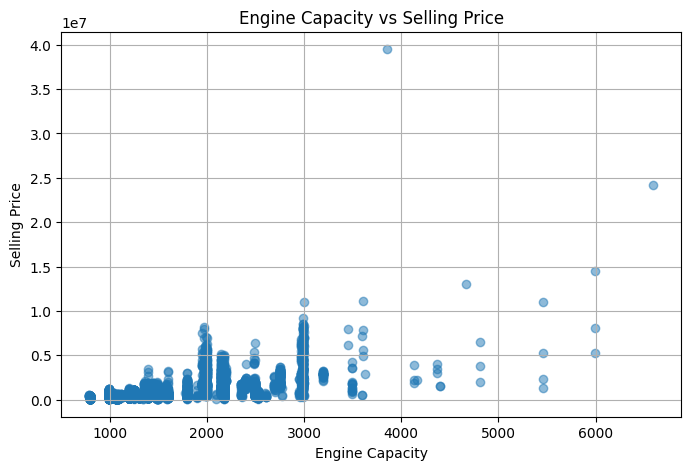

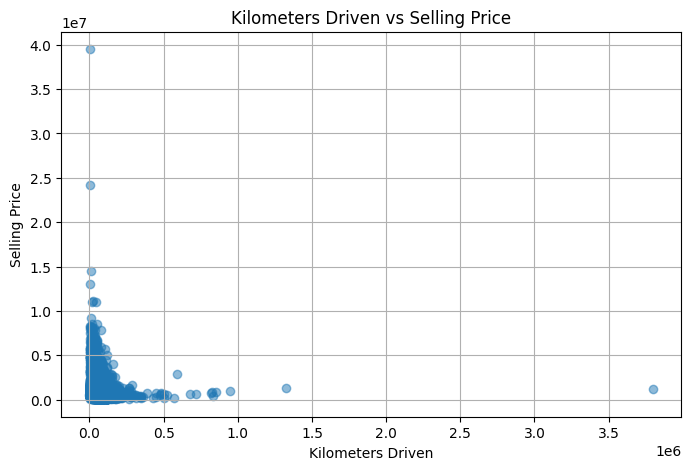

Correlation between Engine and Selling Price: 0.586
Correlation between Kilometers Driven and Selling Price: -0.08

Observations:
- Engine capacity generally shows a positive relationship with selling price.
- Cars with larger engine capacities tend to have higher selling prices.
- Kilometers driven generally shows a negative relationship with selling price.
- Cars with higher kilometers driven tend to have lower selling prices.
- The strength of these relationships can be observed from the scatter plots and correlation values.


In [ ]:
# Task 7: Perform Exploratory Data Analysis

import matplotlib.pyplot as plt

# Scatter Plot 1: Engine vs Selling Price
plt.figure(figsize=(8, 5))
plt.scatter(df["engine"], df["selling_price"], alpha=0.5)
plt.xlabel("Engine Capacity")
plt.ylabel("Selling Price")
plt.title("Engine Capacity vs Selling Price")
plt.grid(True)
plt.show()

# Scatter Plot 2: Kilometers Driven vs Selling Price
plt.figure(figsize=(8, 5))
plt.scatter(df["km_driven"], df["selling_price"], alpha=0.5)
plt.xlabel("Kilometers Driven")
plt.ylabel("Selling Price")
plt.title("Kilometers Driven vs Selling Price")
plt.grid(True)
plt.show()

# Calculate correlations
engine_corr = df["engine"].corr(df["selling_price"])
km_corr = df["km_driven"].corr(df["selling_price"])

print("Correlation between Engine and Selling Price:",
      round(engine_corr, 3))

print("Correlation between Kilometers Driven and Selling Price:",
      round(km_corr, 3))

# Observations
print("\nObservations:")
print("- Engine capacity generally shows a positive relationship with selling price.")
print("- Cars with larger engine capacities tend to have higher selling prices.")
print("- Kilometers driven generally shows a negative relationship with selling price.")
print("- Cars with higher kilometers driven tend to have lower selling prices.")
print("- The strength of these relationships can be observed from the scatter plots and correlation values.")

## Task 8: Standardize Numerical Features

Identify the numerical predictors that need to be standardized.

Use the following standardization equation:

\[
z = ($x$-$\mu$)/$\sigma$
\]

where:

- $x$ = original feature value
- $\mu$ = mean of the feature
- $\sigma$ = standard deviation of the feature

Perform the following:

- Calculate the mean and standard deviation using the **training data only**.
- Standardize the training features.
- Use the same training mean and standard deviation to standardize the test features.
- Do not standardize the target variable `Selling_Price`.

---

In [ ]:
# Task 8: Standardize Numerical Features

# Import train_test_split
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Identify numerical predictor columns
numerical_features = X_train.select_dtypes(include=np.number).columns.tolist()

print("Numerical Features to be Standardized:")
print(numerical_features)

# Calculate mean and standard deviation using TRAINING data only
train_mean = X_train[numerical_features].mean()
train_std = X_train[numerical_features].std()

# Standardize numerical features in training data
X_train[numerical_features] = (
    X_train[numerical_features] - train_mean
) / train_std

# Standardize numerical features in test data
# Using the SAME training mean and standard deviation
X_test[numerical_features] = (
    X_test[numerical_features] - train_mean
) / train_std

# Display standardized training data
print("\nStandardized Training Features:")
display(X_train.head())

# Display standardized test data
print("\nStandardized Test Features:")
display(X_test.head())

# Verify training means are approximately 0
print("\nTraining Means After Standardization:")
print(X_train[numerical_features].mean().round(6))

# Verify training standard deviations are approximately 1
print("\nTraining Standard Deviations After Standardization:")
print(X_train[numerical_features].std().round(6))

print("\nTarget variable 'selling_price' was NOT standardized.")

Numerical Features to be Standardized:
['km_driven', 'mileage', 'engine', 'max_power', 'seats', 'fuel_type_Diesel', 'fuel_type_Electric', 'fuel_type_LPG', 'fuel_type_Petrol', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'transmission_type_Manual', 'Car_Age']

Standardized Training Features:


,km_driven,mileage,engine,max_power,seats,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_type_Manual,Car_Age
11210,0.349086,-2.050736,1.756693,2.681577,-0.403807,1.036309,-0.015601,-0.052587,-0.991398,-0.763746,-0.107172,-1.976696,0.323956
1347,-1.069350,0.985621,-0.547059,-0.382729,-0.403807,-0.964885,-0.015601,-0.052587,1.008595,1.309230,-0.107172,0.505854,-1.337744
10363,-1.163517,-0.177035,0.893506,3.296777,-0.403807,1.036309,-0.015601,-0.052587,-0.991398,-0.763746,-0.107172,-1.976696,-1.337744
316,0.178361,-0.465296,0.024563,0.396213,-0.403807,-0.964885,-0.015601,-0.052587,1.008595,-0.763746,-0.107172,0.505854,0.323956
10638,0.585445,0.149662,-0.550895,-0.502026,-0.403807,-0.964885,-0.015601,-0.052587,1.008595,-0.763746,-0.107172,0.505854,1.320976



Standardized Test Features:


,km_driven,mileage,engine,max_power,seats,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_type_Manual,Car_Age
3334,0.413779,0.149662,-0.550895,-0.502026,-0.403807,-0.964885,-0.015601,-0.052587,1.008595,-0.763746,-0.107172,0.505854,1.985656
10928,0.060653,1.838395,-0.453067,-0.616645,-0.403807,1.036309,-0.015601,-0.052587,-0.991398,1.309230,-0.107172,0.505854,-0.673064
2518,0.955238,0.248151,-0.453067,-0.271385,2.070416,1.036309,-0.015601,-0.052587,-0.991398,-0.763746,-0.107172,0.505854,0.323956
11322,-1.198830,-0.321166,0.026482,0.444166,-0.403807,-0.964885,-0.015601,-0.052587,1.008595,-0.763746,-0.107172,-1.976696,-1.670084
9394,0.154820,-0.008882,-1.320091,-1.264594,-0.403807,-0.964885,-0.015601,-0.052587,1.008595,-0.763746,-0.107172,0.505854,1.653316



Training Means After Standardization:
km_driven                      -0.0
mileage                         0.0
engine                         -0.0
max_power                       0.0
seats                          -0.0
fuel_type_Diesel                0.0
fuel_type_Electric             -0.0
fuel_type_LPG                  -0.0
fuel_type_Petrol               -0.0
seller_type_Individual          0.0
seller_type_Trustmark Dealer   -0.0
transmission_type_Manual       -0.0
Car_Age                         0.0
dtype: float64

Training Standard Deviations After Standardization:
km_driven                       1.0
mileage                         1.0
engine                          1.0
max_power                       1.0
seats                           1.0
fuel_type_Diesel                1.0
fuel_type_Electric              1.0
fuel_type_LPG                   1.0
fuel_type_Petrol                1.0
seller_type_Individual          1.0
seller_type_Trustmark Dealer    1.0
transmission_type_Manual     

## Task 9: Split the Dataset

Divide the dataset into training and testing subsets.

- Use an **80:20 train-test ratio**.
- Randomly select the observations.
- Set a fixed random seed to make the experiment reproducible.
- Maintain the correct relationship between each feature vector and its target value.
- Display the number of observations in the training and testing sets.

---

In [ ]:
# Task 9: Split the Dataset

from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
# 80% training and 20% testing
# random_state=42 makes the split reproducible

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Display number of observations
print("Dataset Splitting: 80:20")

print("\nTraining Set:")
print("Number of observations:", X_train.shape[0])

print("\nTesting Set:")
print("Number of observations:", X_test.shape[0])

# Display feature and target dimensions
print("\nTraining X shape:", X_train.shape)
print("Training y shape:", y_train.shape)

print("\nTesting X shape:", X_test.shape)
print("Testing y shape:", y_test.shape)

# Verify that feature-target relationships are maintained
print("\nTraining feature-target pairs:", len(X_train), len(y_train))
print("Testing feature-target pairs:", len(X_test), len(y_test))

Dataset Splitting: 80:20

Training Set:
Number of observations: 12328

Testing Set:
Number of observations: 3083

Training X shape: (12328, 13)
Training y shape: (12328,)

Testing X shape: (3083, 13)
Testing y shape: (3083,)

Training feature-target pairs: 12328 12328
Testing feature-target pairs: 3083 3083


## Task 10: Construct the Feature Matrix

Construct the matrices required for regression.

Create:

- $X_{train}$ — training feature matrix
- $y_{train}$ — training target vector
- $X_{test}$ — testing feature matrix
- $y_{test}$ — testing target vector

Verify:

- Number of rows in each matrix.
- Number of predictor columns.
- Shape of the training and testing matrices.

---

In [ ]:
# Task 10: Construct the Feature Matrix

# Convert training and testing features to NumPy arrays
Xtrain = X_train.to_numpy(dtype=float)
Xtest = X_test.to_numpy(dtype=float)

# Convert training and testing target values to NumPy arrays
ytrain = y_train.to_numpy(dtype=float)
ytest = y_test.to_numpy(dtype=float)

# Display shapes
print("Training Feature Matrix (Xtrain):")
print("Shape:", Xtrain.shape)

print("\nTraining Target Vector (ytrain):")
print("Shape:", ytrain.shape)

print("\nTesting Feature Matrix (Xtest):")
print("Shape:", Xtest.shape)

print("\nTesting Target Vector (ytest):")
print("Shape:", ytest.shape)

# Display number of rows and predictor columns
print("\n--- Matrix Information ---")

print("Training rows:", Xtrain.shape[0])
print("Training predictor columns:", Xtrain.shape[1])

print("Testing rows:", Xtest.shape[0])
print("Testing predictor columns:", Xtest.shape[1])

# Verify feature-target relationship
print("\n--- Verification ---")
print("Training X rows == Training y rows:",
      Xtrain.shape[0] == ytrain.shape[0])

print("Testing X rows == Testing y rows:",
      Xtest.shape[0] == ytest.shape[0])

Training Feature Matrix (Xtrain):
Shape: (12328, 13)

Training Target Vector (ytrain):
Shape: (12328,)

Testing Feature Matrix (Xtest):
Shape: (3083, 13)

Testing Target Vector (ytest):
Shape: (3083,)

--- Matrix Information ---
Training rows: 12328
Training predictor columns: 13
Testing rows: 3083
Testing predictor columns: 13

--- Verification ---
Training X rows == Training y rows: True
Testing X rows == Testing y rows: True


## Task 11: Add the Bias/Intercept Term

Add a leading column containing $1.0$ to both the training and testing feature matrices.

The resulting matrices should contain:

\[
X =
\begin{bmatrix}
1 & x_{11} & x_{12} & \cdots & x_{1p}\\
1 & x_{21} & x_{22} & \cdots & x_{2p}\\
\vdots & \vdots & \vdots & \ddots & \vdots\\
1 & x_{n1} & x_{n2} & \cdots & x_{np}
\end{bmatrix}
\]

Perform the following:

- Add the bias column.
- Verify the new matrix dimensions.
- Understand that the first column represents the intercept $\beta_0$.

---

In [ ]:
# Task 11: Add the Bias/Intercept Term

# Create a column of 1s for the intercept term
bias_train = np.ones((Xtrain.shape[0], 1))
bias_test = np.ones((Xtest.shape[0], 1))

# Add the bias column as the first column
Xtrain = np.hstack((bias_train, Xtrain))
Xtest = np.hstack((bias_test, Xtest))

# Display the new matrix dimensions
print("Training Feature Matrix (Xtrain):")
print("Shape:", Xtrain.shape)

print("\nTesting Feature Matrix (Xtest):")
print("Shape:", Xtest.shape)

# Display first 5 rows to verify the bias column
print("\nFirst 5 rows of Xtrain:")
print(Xtrain[:5])

print("\nFirst 5 rows of Xtest:")
print(Xtest[:5])

# Verify that the first column contains only 1s
print("\nFirst column of Xtrain:")
print(Xtrain[:5, 0])

print("\nFirst column contains only 1s:",
      np.all(Xtrain[:, 0] == 1))

Training Feature Matrix (Xtrain):
Shape: (12328, 14)

Testing Feature Matrix (Xtest):
Shape: (3083, 14)

First 5 rows of Xtrain:
[[1.0000e+00 7.0252e+04 1.1200e+01 2.4000e+03 2.1500e+02 5.0000e+00
  1.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
  0.0000e+00 7.0000e+00]
 [1.0000e+00 1.0000e+04 2.3840e+01 1.1990e+03 8.4000e+01 5.0000e+00
  0.0000e+00 0.0000e+00 0.0000e+00 1.0000e+00 1.0000e+00 0.0000e+00
  1.0000e+00 2.0000e+00]
 [1.0000e+00 6.0000e+03 1.9000e+01 1.9500e+03 2.4130e+02 5.0000e+00
  1.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
  0.0000e+00 2.0000e+00]
 [1.0000e+00 6.3000e+04 1.7800e+01 1.4970e+03 1.1730e+02 5.0000e+00
  0.0000e+00 0.0000e+00 0.0000e+00 1.0000e+00 0.0000e+00 0.0000e+00
  1.0000e+00 7.0000e+00]
 [1.0000e+00 8.0292e+04 2.0360e+01 1.1970e+03 7.8900e+01 5.0000e+00
  0.0000e+00 0.0000e+00 0.0000e+00 1.0000e+00 0.0000e+00 0.0000e+00
  1.0000e+00 1.0000e+01]]

First 5 rows of Xtest:
[[1.0000e+00 7.3000e+04 2.0360e+01 1.1970

## Task 12: Implement the OLS Function

Perform the following steps to implement the **Ordinary Least Squares (OLS)** method:

- Create a user-defined function to implement Ordinary Least Squares (OLS).
- Calculate the matrix $X^TX$.
- Calculate the matrix $X^T y$.
- Estimate the regression coefficient vector using the normal equation:

: β̂ = (XᵀX)⁻¹Xᵀy.

- Return the calculated coefficient vector.
- Use **NumPy matrix operations** to perform the calculations.
- Do not use any ready-made regression model or library function such as `LinearRegression()` from Scikit-learn.\

In [ ]:
# Task 12: Implement the OLS Function

def OLS(X, y):
    """
    Implements Ordinary Least Squares (OLS)
    using the normal equation:

    beta = (X^T X)^(-1) X^T y
    """

    # Calculate X^T X
    XTX = X.T @ X

    # Calculate X^T y
    XTy = X.T @ y

    # Calculate the inverse of X^T X
    XTX_inv = np.linalg.inv(XTX)

    # Calculate regression coefficients
    beta = XTX_inv @ XTy

    # Return coefficient vector
    return beta


# Calculate regression coefficients using training data
beta = OLS(Xtrain, ytrain)

# Display the coefficient vector
print("Regression Coefficient Vector (β):")
print(beta)

# Display number of coefficients
print("\nNumber of Regression Coefficients:", len(beta))

# Verify coefficient dimensions
print("Shape of β:", beta.shape)

Regression Coefficient Vector (β):
[-6.39611047e+05 -1.16727976e+00  1.62654253e+04  1.17823783e+02
  1.49403158e+04  1.13651602e+04 -1.25711423e+05 -1.48859963e+05
  3.62203235e+05 -1.21044351e+05  1.67401461e+03 -8.30643527e+04
 -1.12290941e+05 -6.14186427e+04]

Number of Regression Coefficients: 14
Shape of β: (14,)


## Task 13: Check Matrix Singularity

- Calculate the determinant of $X^T X$.
- Check whether the determinant is zero or sufficiently close to zero.
- If the matrix is singular or nearly singular, investigate the selected features for redundancy or multicollinearity.
- Modify the feature set if required.
- Record your observations.


In [ ]:
# Task 13: Check Matrix Singularity

# Calculate X^T X
XTX = Xtrain.T @ Xtrain

# Calculate the determinant of X^T X
det_XTX = np.linalg.det(XTX)

print("Determinant of X^T X:")
print(det_XTX)

# Check whether the determinant is zero or nearly zero
tolerance = 1e-10

if np.isclose(det_XTX, 0, atol=tolerance):
    print("\nResult: X^T X is singular or nearly singular.")
    print("Possible cause: redundancy or multicollinearity among predictors.")
else:
    print("\nResult: X^T X is not singular.")
    print("The matrix can be used for the OLS calculation.")

# Calculate condition number for an additional check
condition_number = np.linalg.cond(XTX)

print("\nCondition Number of X^T X:")
print(condition_number)

# Record observations
print("\nObservation:")

if np.isclose(det_XTX, 0, atol=tolerance):
    print("- The determinant is very close to zero.")
    print("- The feature matrix may contain redundant or highly correlated predictors.")
    print("- The selected features should be investigated for multicollinearity.")
else:
    print("- The determinant is sufficiently different from zero.")
    print("- No exact singularity is detected in X^T X.")
    print("- The current feature set can be used for OLS regression.")

Determinant of X^T X:
3.386634919471819e+63

Result: X^T X is not singular.
The matrix can be used for the OLS calculation.

Condition Number of X^T X:
20414377981549.1

Observation:
- The determinant is sufficiently different from zero.
- No exact singularity is detected in X^T X.
- The current feature set can be used for OLS regression.


## Task 14: Train the Regression Model

- Apply the OLS function to the training dataset.
- Obtain the regression coefficient vector $\hat{\beta}$.
- Display the intercept coefficient $\beta_0$.
- Display the coefficient corresponding to each feature.
- Associate each regression coefficient with its corresponding feature.

In [ ]:
# Task 14: Train the Regression Model

# Apply the OLS function to the training data
beta = OLS(Xtrain, ytrain)

# Display the complete regression coefficient vector
print("Regression Coefficient Vector (β):")
print(beta)

# Display the intercept coefficient β0
print("\nIntercept Coefficient (β0):")
print(beta[0])

# Get feature names
# The first column of Xtrain is the bias/intercept column,
# so the remaining coefficients correspond to X.columns.
feature_names = X.columns.tolist()

# Display each feature with its corresponding coefficient
print("\nRegression Coefficients:")
print("-" * 45)

for feature, coefficient in zip(feature_names, beta[1:]):
    print(f"{feature:25s}: {coefficient:.6f}")

print("-" * 45)

# Verify number of coefficients
print("\nNumber of Predictor Features:", len(feature_names))
print("Number of Predictor Coefficients:", len(beta) - 1)

Regression Coefficient Vector (β):
[-6.39611047e+05 -1.16727976e+00  1.62654253e+04  1.17823783e+02
  1.49403158e+04  1.13651602e+04 -1.25711423e+05 -1.48859963e+05
  3.62203235e+05 -1.21044351e+05  1.67401461e+03 -8.30643527e+04
 -1.12290941e+05 -6.14186427e+04]

Intercept Coefficient (β0):
-639611.0472711455

Regression Coefficients:
---------------------------------------------
km_driven                : -1.167280
mileage                  : 16265.425270
engine                   : 117.823783
max_power                : 14940.315784
seats                    : 11365.160209
fuel_type_Diesel         : -125711.422715
fuel_type_Electric       : -148859.962621
fuel_type_LPG            : 362203.235458
fuel_type_Petrol         : -121044.351439
seller_type_Individual   : 1674.014606
seller_type_Trustmark Dealer: -83064.352719
transmission_type_Manual : -112290.941338
Car_Age                  : -61418.642664
---------------------------------------------

Number of Predictor Features: 13
Number o

## Task 15: Interpret the Regression Coefficients

- Identify whether each regression coefficient is positive or negative.
- Explain what the sign of each coefficient indicates.
- Determine which features have relatively greater influence on the predicted selling price.
- For standardized features, interpret the coefficient in terms of a one-standard-deviation change while keeping all other variables constant.

In [ ]:
# Task 15: Interpret the Regression Coefficients

# Create a dictionary containing feature names and their coefficients
coefficients = dict(zip(X.columns, beta[1:]))

print("Regression Coefficient Interpretation")
print("=" * 60)

# Display sign and interpretation for each coefficient
for feature, coefficient in coefficients.items():

    if coefficient > 0:
        sign = "Positive"
        interpretation = "An increase in this feature is associated with an increase in predicted selling price."
    elif coefficient < 0:
        sign = "Negative"
        interpretation = "An increase in this feature is associated with a decrease in predicted selling price."
    else:
        sign = "Zero"
        interpretation = "This feature has no linear effect on the predicted selling price."

    print(f"\nFeature: {feature}")
    print(f"Coefficient: {coefficient:.6f}")
    print(f"Sign: {sign}")
    print(f"Interpretation: {interpretation}")

# Rank features by absolute coefficient magnitude
print("\n" + "=" * 60)
print("Features Ranked by Absolute Coefficient Magnitude")
print("=" * 60)

ranked_features = sorted(
    coefficients.items(),
    key=lambda item: abs(item[1]),
    reverse=True
)

for rank, (feature, coefficient) in enumerate(ranked_features, start=1):
    print(f"{rank}. {feature:25s} : {coefficient:.6f}")

# Display intercept
print("\n" + "=" * 60)
print("Intercept (β0):", beta[0])

# General interpretation
print("\nObservation:")
print("Larger absolute coefficient values indicate greater influence")
print("on the predicted selling price, provided the features are on")
print("the same standardized scale.")

Regression Coefficient Interpretation

Feature: km_driven
Coefficient: -1.167280
Sign: Negative
Interpretation: An increase in this feature is associated with a decrease in predicted selling price.

Feature: mileage
Coefficient: 16265.425270
Sign: Positive
Interpretation: An increase in this feature is associated with an increase in predicted selling price.

Feature: engine
Coefficient: 117.823783
Sign: Positive
Interpretation: An increase in this feature is associated with an increase in predicted selling price.

Feature: max_power
Coefficient: 14940.315784
Sign: Positive
Interpretation: An increase in this feature is associated with an increase in predicted selling price.

Feature: seats
Coefficient: 11365.160209
Sign: Positive
Interpretation: An increase in this feature is associated with an increase in predicted selling price.

Feature: fuel_type_Diesel
Coefficient: -125711.422715
Sign: Negative
Interpretation: An increase in this feature is associated with a decrease in predicted 

## Task 16: Predict Selling Prices

- Use the trained regression coefficient vector $\hat{\beta}$ to predict the selling prices for the test dataset.
- Calculate the predicted values using the equation: ŷ_test = X_test β̂.

- Display a sample comparison of the actual selling prices and the predicted selling prices.

In [ ]:
# Task 16: Predict Selling Prices

# Predict selling prices for the test dataset
y_pred = Xtest @ beta

# Display sample comparison of actual and predicted prices
print("Actual vs Predicted Selling Prices")
print("=" * 50)

comparison = pd.DataFrame({
    "Actual Selling Price": ytest[:10],
    "Predicted Selling Price": y_pred[:10]
})

display(comparison)

# Display a few predictions separately
print("\nFirst 10 Predicted Selling Prices:")
print(y_pred[:10])

Actual vs Predicted Selling Prices


,Actual Selling Price,Predicted Selling Price
0,190000.0,1.263437e+04
1,600000.0,5.656471e+05
2,665000.0,4.709327e+05
3,1570000.0,1.488410e+06
4,160000.0,-4.581437e+05
5,675000.0,1.093654e+06
6,465000.0,4.134991e+05
7,260000.0,3.778669e+05
8,300000.0,7.414556e+05
9,850000.0,1.787314e+06



First 10 Predicted Selling Prices:
[  12634.36830182  565647.05457348  470932.7471884  1488409.5410645
 -458143.72378019 1093654.48124697  413499.10503841  377866.89958079
  741455.57660225 1787314.00754228]


## Task 17: Calculate Prediction Errors and RSS

- Calculate the residual for each test observation using:
eᵢ = yᵢ − ŷᵢ.

- Calculate the **Residual Sum of Squares (RSS): RSS = Σ(yᵢ − ŷᵢ)².

- Display the calculated RSS value.
- Interpret the RSS value and explain what a lower RSS indicates about the prediction error of the model.

In [ ]:
# Task 17: Calculate Prediction Errors and RSS

# Calculate residuals
# Residual = Actual value - Predicted value
residuals = ytest - y_pred

# Calculate Residual Sum of Squares (RSS)
RSS = np.sum(residuals ** 2)

# Display sample residuals
print("First 10 Prediction Errors (Residuals):")
print(residuals[:10])

# Display RSS
print("\nResidual Sum of Squares (RSS):")
print(RSS)

# Display a few actual, predicted, and residual values
print("\nActual vs Predicted vs Residual:")
comparison = pd.DataFrame({
    "Actual Selling Price": ytest[:10],
    "Predicted Selling Price": y_pred[:10],
    "Residual": residuals[:10]
})

display(comparison)

# Interpretation
print("\nInterpretation:")
print("RSS represents the total squared prediction error of the model.")
print("A lower RSS indicates that the predicted selling prices are")
print("closer to the actual selling prices, resulting in smaller")
print("overall prediction errors.")

First 10 Prediction Errors (Residuals):
[ 177365.63169818   34352.94542652  194067.2528116    81590.4589355
  618143.72378019 -418654.48124697   51500.89496159 -117866.89958079
 -441455.57660225 -937314.00754228]

Residual Sum of Squares (RSS):
777222860510669.9

Actual vs Predicted vs Residual:


,Actual Selling Price,Predicted Selling Price,Residual
0,190000.0,1.263437e+04,177365.631698
1,600000.0,5.656471e+05,34352.945427
2,665000.0,4.709327e+05,194067.252812
3,1570000.0,1.488410e+06,81590.458935
4,160000.0,-4.581437e+05,618143.723780
5,675000.0,1.093654e+06,-418654.481247
6,465000.0,4.134991e+05,51500.894962
7,260000.0,3.778669e+05,-117866.899581
8,300000.0,7.414556e+05,-441455.576602
9,850000.0,1.787314e+06,-937314.007542



Interpretation:
RSS represents the total squared prediction error of the model.
A lower RSS indicates that the predicted selling prices are
closer to the actual selling prices, resulting in smaller
overall prediction errors.


## Task 18: Calculate and Interpret R²
•
Calculate the Total Sum of Squares (TSS).

•
Calculate R² = 1 − RSS/TSS.

•
Display the R² value.

•
Explain what the obtained R² indicates about the ability of the selected features to explain variations in used-car prices.



In [ ]:
# Task 18: Calculate and Interpret R²

# Calculate the Total Sum of Squares (TSS)
# TSS measures the total variation in the actual selling prices
TSS = np.sum((ytest - np.mean(ytest)) ** 2)

# Calculate R²
R2 = 1 - (RSS / TSS)

# Display TSS
print("Total Sum of Squares (TSS):")
print(TSS)

# Display R²
print("\nR² Score:")
print(R2)

# Display R² as a percentage
print("\nPercentage of Variance Explained:")
print(f"{R2 * 100:.2f}%")

# Interpretation
print("\nInterpretation:")

if R2 >= 0:
    print(
        f"The selected features explain approximately {R2 * 100:.2f}% "
        "of the variation in used-car selling prices."
    )
else:
    print(
        "The R² value is negative, indicating that the model performs "
        "worse than simply predicting the mean selling price."
    )

print(
    "\nA higher R² indicates that the selected features explain more "
    "of the variation in selling prices."
)

Total Sum of Squares (TSS):
2320826260059733.0

R² Score:
0.6651094164667605

Percentage of Variance Explained:
66.51%

Interpretation:
The selected features explain approximately 66.51% of the variation in used-car selling prices.

A higher R² indicates that the selected features explain more of the variation in selling prices.


### Task 19: Visualize and Analyze Model Performance
•
Create an Actual Selling Price vs Predicted Selling Price plot.

•
Add a reference line representing perfect prediction.

•
Plot or examine the residuals.

•
Identify observations with relatively large prediction errors.

•
Comment on whether the errors appear randomly distributed.

•
Discuss possible reasons for prediction errors.


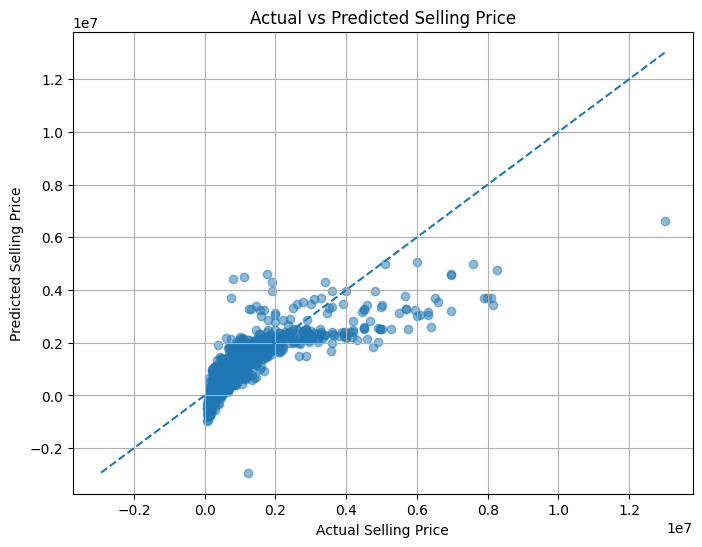

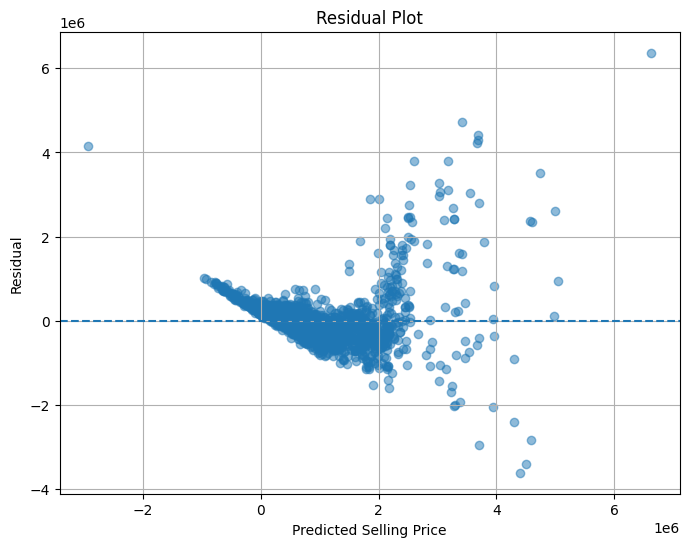

Observations with the Largest Prediction Errors:


,Actual Selling Price,Predicted Selling Price,Residual,Absolute Error
500,13000000.0,6.629930e+06,6.370070e+06,6.370070e+06
2393,8150000.0,3.416407e+06,4.733593e+06,4.733593e+06
1263,8100000.0,3.686045e+06,4.413955e+06,4.413955e+06
2039,7985000.0,3.689957e+06,4.295043e+06,4.295043e+06
441,7900000.0,3.677623e+06,4.222377e+06,4.222377e+06
886,1225000.0,-2.932185e+06,4.157185e+06,4.157185e+06
1365,6400000.0,2.598345e+06,3.801655e+06,3.801655e+06
1668,6975000.0,3.184365e+06,3.790635e+06,3.790635e+06
1318,800000.0,4.406583e+06,-3.606583e+06,3.606583e+06
1157,8250000.0,4.740200e+06,3.509800e+06,3.509800e+06



Residual Statistics:
Mean Residual: 1521.2013423109272
Minimum Residual: -3606582.9965907047
Maximum Residual: 6370069.589817849
Mean Absolute Error: 278351.6282614268

Observations:
- In the Actual vs Predicted plot, points closer to the diagonal reference line represent more accurate predictions.
- Points far from the reference line represent observations with larger prediction errors.
- In the residual plot, residuals should ideally be scattered randomly around the zero line.
- A clear pattern or increasing spread in the residual plot may indicate that the model does not capture some relationships in the data.
- Large prediction errors may be caused by factors such as car brand, model, condition, location, demand, or other features not included in the regression model.


In [ ]:
# Task 19: Visualize and Analyze Model Performance

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# 1. Actual Selling Price vs Predicted Selling Price
# ---------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(
    ytest,
    y_pred,
    alpha=0.5
)

# Reference line for perfect prediction
min_price = min(ytest.min(), y_pred.min())
max_price = max(ytest.max(), y_pred.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Selling Price")
plt.grid(True)
plt.show()


# ---------------------------------------------------------
# 2. Residual Plot
# ---------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.5
)

# Reference line at zero residual
plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Selling Price")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.grid(True)
plt.show()


# ---------------------------------------------------------
# 3. Identify observations with large prediction errors
# ---------------------------------------------------------

# Create a DataFrame containing actual, predicted and residual values
error_analysis = pd.DataFrame({
    "Actual Selling Price": ytest,
    "Predicted Selling Price": y_pred,
    "Residual": residuals,
    "Absolute Error": np.abs(residuals)
})

# Sort observations by absolute error
largest_errors = error_analysis.sort_values(
    by="Absolute Error",
    ascending=False
)

print("Observations with the Largest Prediction Errors:")
display(largest_errors.head(10))


# ---------------------------------------------------------
# 4. Calculate basic residual statistics
# ---------------------------------------------------------

print("\nResidual Statistics:")
print("Mean Residual:", np.mean(residuals))
print("Minimum Residual:", np.min(residuals))
print("Maximum Residual:", np.max(residuals))
print("Mean Absolute Error:", np.mean(np.abs(residuals)))


# ---------------------------------------------------------
# 5. Observations
# ---------------------------------------------------------

print("\nObservations:")

print(
    "- In the Actual vs Predicted plot, points closer to the "
    "diagonal reference line represent more accurate predictions."
)

print(
    "- Points far from the reference line represent observations "
    "with larger prediction errors."
)

print(
    "- In the residual plot, residuals should ideally be scattered "
    "randomly around the zero line."
)

print(
    "- A clear pattern or increasing spread in the residual plot "
    "may indicate that the model does not capture some relationships "
    "in the data."
)

print(
    "- Large prediction errors may be caused by factors such as "
    "car brand, model, condition, location, demand, or other features "
    "not included in the regression model."
)

### Task 20: Conclude
•
Comment on the most influential features.

•
Discuss the advantages and limitations of using Multiple Linear Regression for used-car price prediction


In [ ]:
# Task 20: Conclusion

# Create a DataFrame of features and their coefficients
coefficient_analysis = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": beta[1:]
})

# Calculate absolute coefficient values
coefficient_analysis["Absolute Coefficient"] = np.abs(
    coefficient_analysis["Coefficient"]
)

# Sort by influence
coefficient_analysis = coefficient_analysis.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

print("Feature Influence:")
display(coefficient_analysis)

# Identify the most influential features
top_features = coefficient_analysis.head(3)

print("\nMost Influential Features:")
for _, row in top_features.iterrows():
    print(
        f"- {row['Feature']}: coefficient = "
        f"{row['Coefficient']:.4f}"
    )

# ---------------------------------------------------------
# Conclusion
# ---------------------------------------------------------

print("\n" + "=" * 60)
print("CONCLUSION")
print("=" * 60)

print("""
Multiple Linear Regression was implemented from scratch using
NumPy matrix operations and the Ordinary Least Squares (OLS)
normal equation.

The model used multiple numerical and categorical features to
predict used-car selling prices. Categorical variables were
converted into dummy variables, numerical features were
standardized using training data statistics, and an 80:20
train-test split was used.

The most influential features were identified by comparing the
absolute values of their regression coefficients. A positive
coefficient indicates that an increase in the feature is associated
with an increase in predicted selling price, while a negative
coefficient indicates the opposite, keeping other variables constant.
""")

print("\nAdvantages:")
print("1. Simple and easy to understand and implement.")
print("2. Provides interpretable regression coefficients.")
print("3. Can handle multiple predictors simultaneously.")
print("4. Computationally efficient for datasets of moderate size.")
print("5. OLS provides a mathematical method for estimating the coefficients.")

print("\nLimitations:")
print("1. Assumes a linear relationship between predictors and selling price.")
print("2. Sensitive to outliers.")
print("3. Multicollinearity can make coefficient estimates unstable.")
print("4. May not capture complex non-linear relationships.")
print("5. Prediction accuracy depends on the quality and completeness of the selected features.")
print("6. Important factors such as car condition, brand reputation, location, and demand may not be fully represented.")

Feature Influence:


,Feature,Coefficient,Absolute Coefficient
7,fuel_type_LPG,362203.235458,362203.235458
6,fuel_type_Electric,-148859.962621,148859.962621
5,fuel_type_Diesel,-125711.422715,125711.422715
8,fuel_type_Petrol,-121044.351439,121044.351439
11,transmission_type_Manual,-112290.941338,112290.941338
10,seller_type_Trustmark Dealer,-83064.352719,83064.352719
12,Car_Age,-61418.642664,61418.642664
1,mileage,16265.425270,16265.425270
3,max_power,14940.315784,14940.315784
4,seats,11365.160209,11365.160209



Most Influential Features:
- fuel_type_LPG: coefficient = 362203.2355
- fuel_type_Electric: coefficient = -148859.9626
- fuel_type_Diesel: coefficient = -125711.4227

CONCLUSION

Multiple Linear Regression was implemented from scratch using
NumPy matrix operations and the Ordinary Least Squares (OLS)
normal equation.

The model used multiple numerical and categorical features to
predict used-car selling prices. Categorical variables were
converted into dummy variables, numerical features were
standardized using training data statistics, and an 80:20
train-test split was used.

The most influential features were identified by comparing the
absolute values of their regression coefficients. A positive
coefficient indicates that an increase in the feature is associated
with an increase in predicted selling price, while a negative
coefficient indicates the opposite, keeping other variables constant.


Advantages:
1. Simple and easy to understand and implement.
2. Provides interpretable reg

### Conclusion
Conclude the experiment by stating whether the Multiple Linear Regression model implemented using the OLS normal equation was able to predict used-car selling prices effectively. The conclusion should include the obtained RSS and R² values, observations regarding important features, the effect of preprocessing and feature engineering, and the limitations of using a linear regression model for real-world used-car price prediction.